In [ ]:
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers,Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import SGD,Adam,RMSprop
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
import tensorflow_datasets as tfds


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
plt.rcParams["font.family"]="Times New Roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

In [3]:
IMG_SIZE=224
BATCH_SIZE=32
NUM_CLASSES=37
EPOCHS=5
FINE_TUNE_EPOCHS=5
DATASET_PATH="oxford_iiit_pet"

In [4]:
train_raw,test_raw=tfds.load(
    DATASET_PATH,
    split=["train","test"],
    as_supervised=True,
    shuffle_files=True
)

train_labels=None
test_labels=None

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1787719980.192119      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [5]:
dataset=train_raw.concatenate(test_raw)

dataset=dataset.map(
    lambda image,label: (
        tf.image.resize(image,(IMG_SIZE,IMG_SIZE)),
        tf.cast(label,tf.int32)
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

dataset=dataset.shuffle(
    5000,
    seed=42,
    reshuffle_each_iteration=False
)

images=[]
labels=[]

for image,label in dataset:
    images.append(image.numpy())
    labels.append(label.numpy())

images=np.array(images,dtype=np.float32)
labels=np.array(labels,dtype=np.int32)

print("Images:",images.shape)
print("Images dtype:",images.dtype)
print("Labels:",labels.shape)
print("Labels dtype:",labels.dtype)

Images: (7349, 224, 224, 3)
Images dtype: float32
Labels: (7349,)
Labels dtype: int32


In [6]:
indices=np.random.permutation(len(images))

images=images[indices]
labels=labels[indices]

n=len(images)
train_end=int(0.70*n)
val_end=int(0.85*n)

x_train=images[:train_end]
y_train=labels[:train_end]

x_val=images[train_end:val_end]
y_val=labels[train_end:val_end]

x_test=images[val_end:]
y_test=labels[val_end:]

print("Training:",x_train.shape)
print("Validation:",x_val.shape)
print("Testing:",x_test.shape)

Training: (5144, 224, 224, 3)
Validation: (1102, 224, 224, 3)
Testing: (1103, 224, 224, 3)


In [7]:
x_train=preprocess_input(x_train)
x_val=preprocess_input(x_val)
x_test=preprocess_input(x_test)

In [8]:
def make_dataset(x,y,batch_size=BATCH_SIZE,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((x,y))
    if shuffle:
        ds=ds.shuffle(5000,seed=42)
    ds=ds.batch(batch_size)
    ds=ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds=make_dataset(x_train,y_train,BATCH_SIZE,True)
val_ds=make_dataset(x_val,y_val,BATCH_SIZE,False)
test_ds=make_dataset(x_test,y_test,BATCH_SIZE,False)

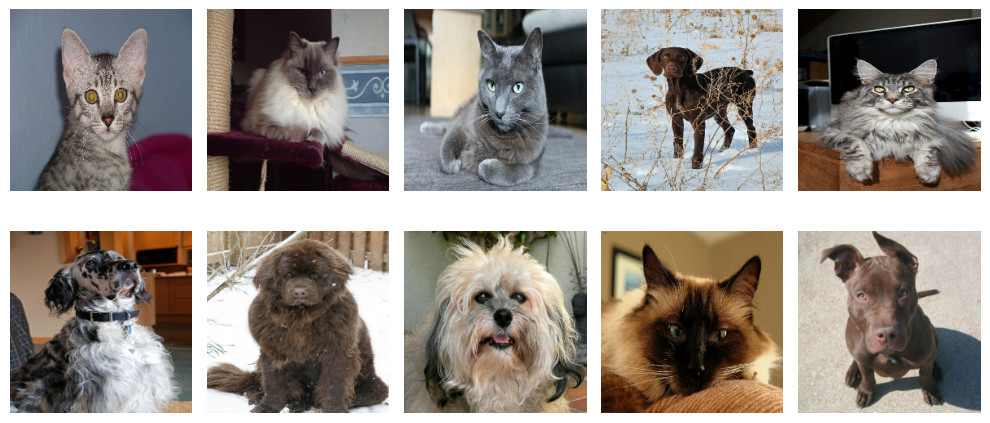

In [9]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow((x_train[i]+1)/2)
    plt.axis("off")

plt.tight_layout()
plt.savefig("images/sample_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [10]:
def build_model(initializer="he_normal",regularization=None,dropout=0.0,batch_norm=False,trainable=False):
    base=MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    base.trainable=trainable

    inputs=layers.Input(shape=(224,224,3))
    x=base(inputs,training=False)
    x=layers.GlobalAveragePooling2D()(x)

    if batch_norm:
        x=layers.BatchNormalization()(x)

    x=layers.Dense(
        128,
        activation="relu",
        kernel_initializer=initializer,
        kernel_regularizer=regularization
    )(x)

    if dropout>0:
        x=layers.Dropout(dropout)(x)

    outputs=layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer
    )(x)

    model=Model(inputs,outputs)

    return model

In [11]:
initializers={
    "Zero":"zeros",
    "Random":"random_normal",
    "Xavier":"glorot_uniform",
    "He":"he_normal"
}

init_histories={}
init_results={}

for name,initializer in initializers.items():

    model=build_model(initializer=initializer)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    init_histories[name]=history.history
    init_results[name]=max(history.history["val_accuracy"])

print(init_results)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5


I0000 00:00:1787720032.440567      91 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step - accuracy: 0.0253 - loss: 3.6112 - val_accuracy: 0.0181 - val_loss: 3.6116
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.0272 - loss: 3.6109 - val_accuracy: 0.0181 - val_loss: 3.6123
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.0301 - loss: 3.6108 - val_accuracy: 0.0181 - val_loss: 3.6130
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.0301 - loss: 3.6106 - val_accuracy: 0.0181 - val_loss: 3.6135
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.0282 - loss: 3.6105 - val_accuracy: 0.0181 - val_loss: 3.6141
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - accuracy: 0.7632 - loss: 0.9587 - val_accuracy: 0.9083 - val_loss: 0.3200
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9228 - loss: 0.2438 - val_accuracy: 0.8956 - val_loss: 0.3105
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9528 - loss: 0.1529 - val_accuracy: 0.9020 -

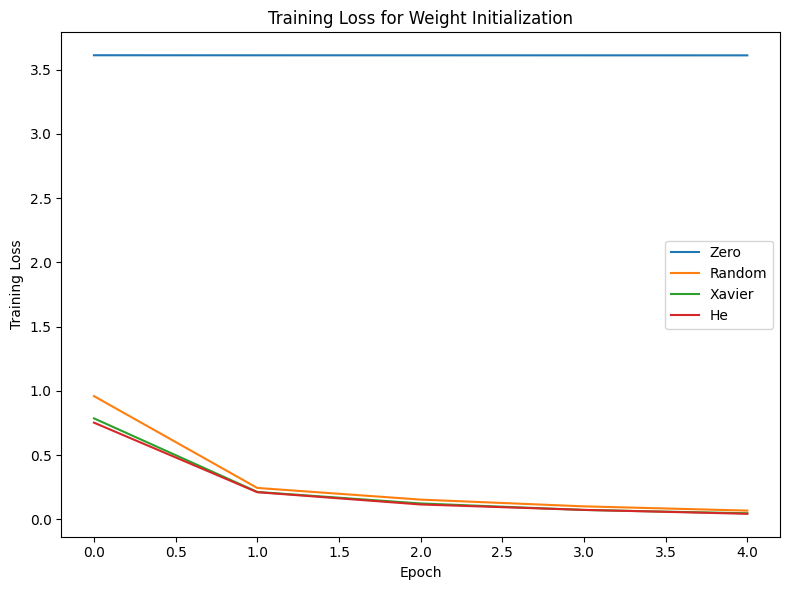

In [12]:
plt.figure(figsize=(8,6))

for name,h in init_histories.items():
    plt.plot(h["loss"],label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Weight Initialization")
plt.legend()
plt.tight_layout()
plt.savefig("images/initialization_training_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

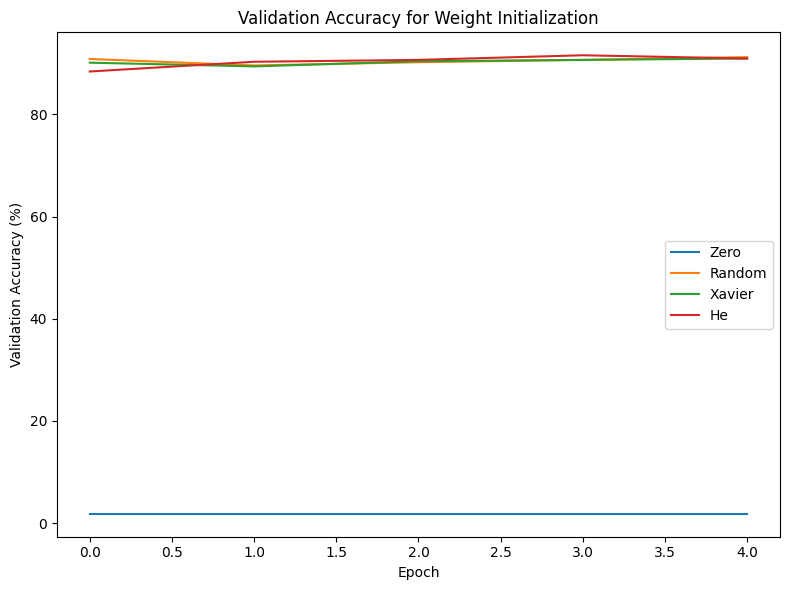

In [13]:
plt.figure(figsize=(8,6))

for name,h in init_histories.items():
    plt.plot(np.array(h["val_accuracy"])*100,label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Weight Initialization")
plt.legend()
plt.tight_layout()
plt.savefig("images/initialization_validation_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [14]:
regularization_configs={
    "No Regularization":{},
    "L2":{"regularization":l2(0.001)},
    "Dropout":{"dropout":0.5},
    "Batch Normalization":{"batch_norm":True}
}

regularization_histories={}
regularization_results={}

for name,config in regularization_configs.items():

    model=build_model(**config)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    regularization_histories[name]=history.history
    regularization_results[name]=max(history.history["val_accuracy"])

print(regularization_results)

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.7827 - loss: 0.7866 - val_accuracy: 0.8893 - val_loss: 0.3597
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9347 - loss: 0.2071 - val_accuracy: 0.9111 - val_loss: 0.2806
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9644 - loss: 0.1179 - val_accuracy: 0.9120 - val_loss: 0.2766
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9815 - loss: 0.0697 - val_accuracy: 0.9093 - val_loss: 0.2991
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9916 - loss: 0.0448 - val_accuracy: 0.9138 - val_loss: 0.2945
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.7817 - loss: 1.0565 - val_accuracy: 0.8956 - val_loss: 0.5985
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9288 - loss: 0.4635 - val_accuracy: 0.8911 - val_loss: 0.5850
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9584 - loss: 0.3552 - val_accuracy: 

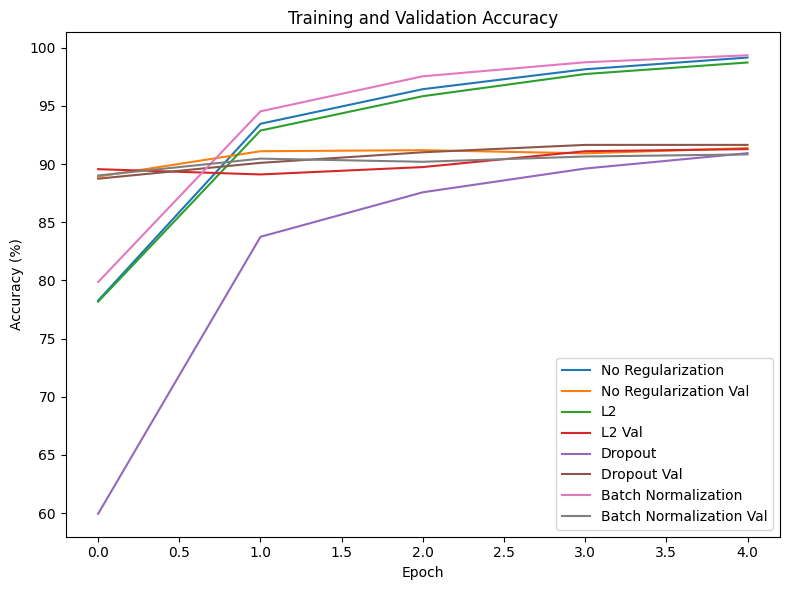

In [15]:
plt.figure(figsize=(8,6))

for name,h in regularization_histories.items():
    plt.plot(np.array(h["accuracy"])*100,label=name)
    plt.plot(np.array(h["val_accuracy"])*100,label=name+" Val")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("images/regularization_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

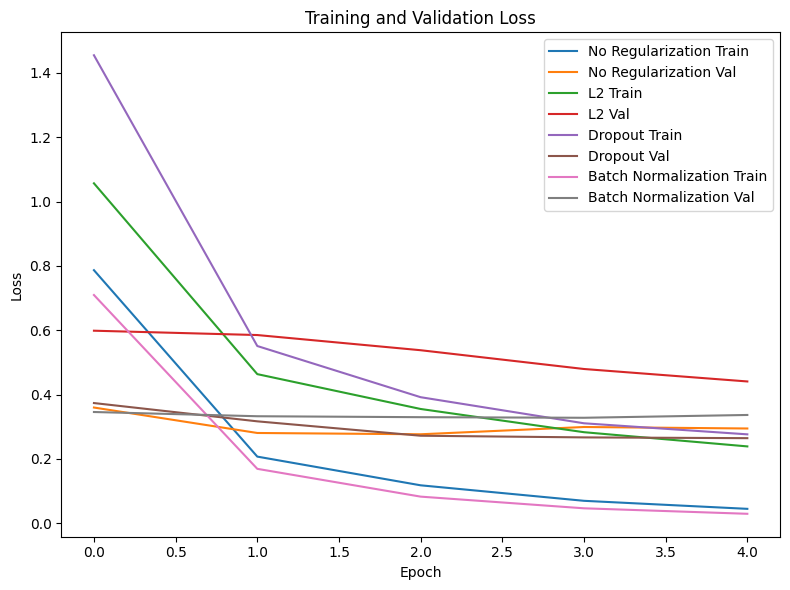

In [16]:
plt.figure(figsize=(8,6))

for name,h in regularization_histories.items():
    plt.plot(h["loss"],label=name+" Train")
    plt.plot(h["val_loss"],label=name+" Val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("images/regularization_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [17]:
bn_results={
    "Without BN":regularization_results["No Regularization"],
    "With BN":regularization_results["Batch Normalization"]
}

print(bn_results)

{'Without BN': 0.9137930870056152, 'With BN': 0.9083484411239624}


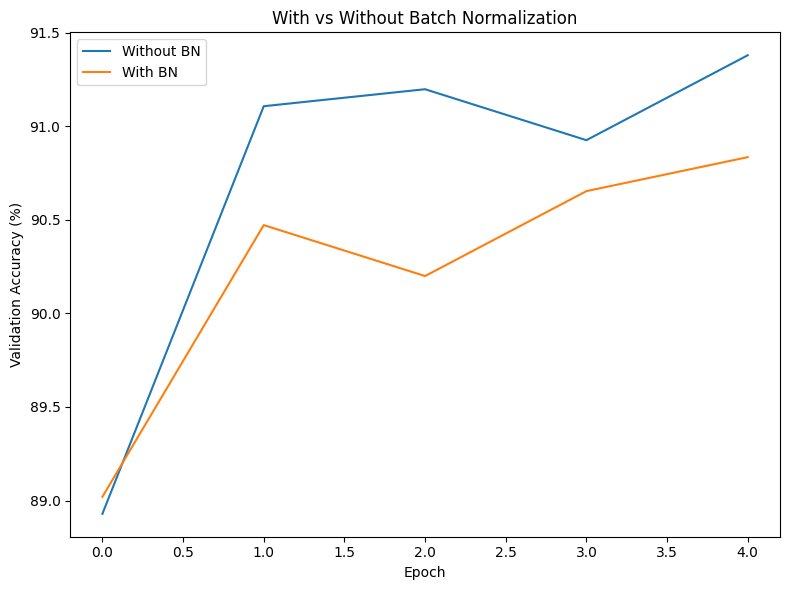

In [18]:
plt.figure(figsize=(8,6))

plt.plot(
    np.array(regularization_histories["No Regularization"]["val_accuracy"])*100,
    label="Without BN"
)

plt.plot(
    np.array(regularization_histories["Batch Normalization"]["val_accuracy"])*100,
    label="With BN"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("With vs Without Batch Normalization")
plt.legend()
plt.tight_layout()
plt.savefig("images/batch_normalization.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [19]:
optimizers={
    "SGD":SGD(learning_rate=0.001),
    "Momentum":SGD(learning_rate=0.001,momentum=0.9),
    "RMSProp":RMSprop(learning_rate=0.001),
    "Adam":Adam(learning_rate=0.001)
}

optimizer_histories={}
optimizer_results={}

for name,optimizer in optimizers.items():

    model=build_model()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start=time.time()

    history=model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    elapsed=time.time()-start

    optimizer_histories[name]=history.history

    optimizer_results[name]=[
        history.history["loss"][-1],
        max(history.history["val_accuracy"]),
        elapsed
    ]

optimizer_table=pd.DataFrame(
    optimizer_results,
    index=["Final Loss","Best Validation Accuracy","Training Time"]
).T

print(optimizer_table)

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.0525 - loss: 3.6334 - val_accuracy: 0.0726 - val_loss: 3.4087
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.1444 - loss: 3.2231 - val_accuracy: 0.1960 - val_loss: 3.0415
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2920 - loss: 2.8645 - val_accuracy: 0.3666 - val_loss: 2.6993
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4395 - loss: 2.5238 - val_accuracy: 0.5000 - val_loss: 2.3714
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.5630 - loss: 2.2030 - val_accuracy: 0.5971 - val_loss: 2.0652
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.4176 - loss: 2.4981 - val_accuracy: 0.7777 - val_loss: 1.2776
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8262 - loss: 0.8460 - val_accuracy: 0.8711 - val_loss: 0.6036
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8812 - loss: 0.5010 - val_accuracy: 

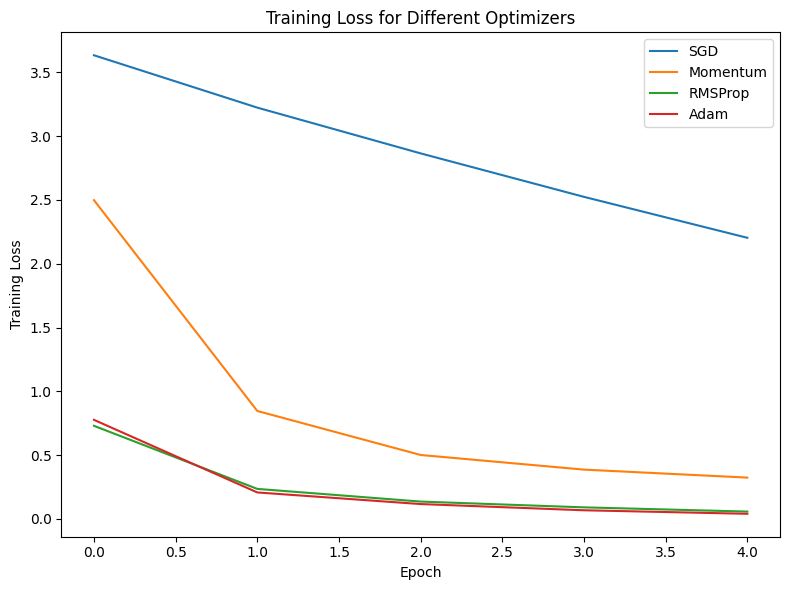

In [20]:
plt.figure(figsize=(8,6))

for name,h in optimizer_histories.items():
    plt.plot(h["loss"],label=name)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Optimizers")
plt.legend()
plt.tight_layout()
plt.savefig("images/optimizer_training_loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

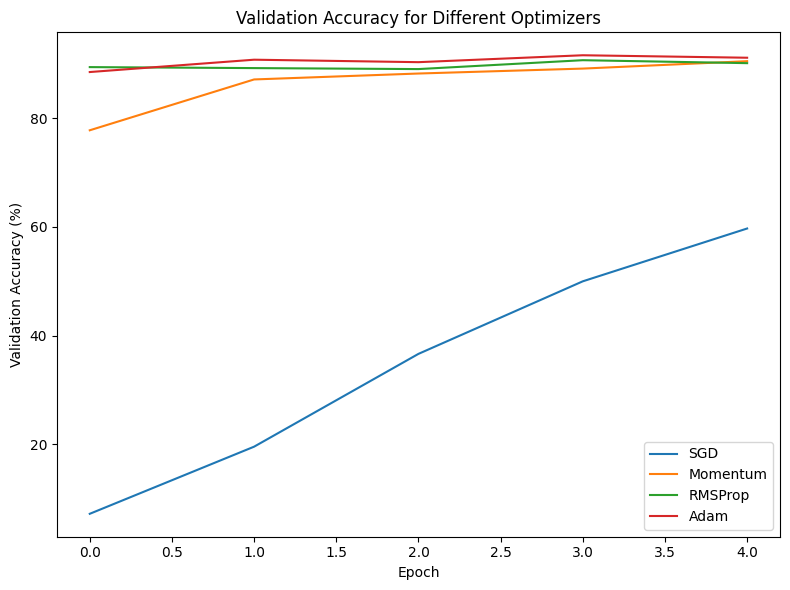

In [21]:
plt.figure(figsize=(8,6))

for name,h in optimizer_histories.items():
    plt.plot(np.array(h["val_accuracy"])*100,label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Different Optimizers")
plt.legend()
plt.tight_layout()
plt.savefig("images/optimizer_validation_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [22]:
learning_rates=[0.001,0.0001]
learning_rate_results={}

for lr in learning_rates:

    model=build_model()

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    learning_rate_results[lr]=max(history.history["val_accuracy"])

print(learning_rate_results)

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - accuracy: 0.7893 - loss: 0.7670 - val_accuracy: 0.8875 - val_loss: 0.3475
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9314 - loss: 0.2006 - val_accuracy: 0.9065 - val_loss: 0.3132
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9646 - loss: 0.1117 - val_accuracy: 0.8884 - val_loss: 0.3568
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9827 - loss: 0.0692 - val_accuracy: 0.9056 - val_loss: 0.3087
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9928 - loss: 0.0407 - val_accuracy: 0.9129 - val_loss: 0.3081
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.3678 - loss: 2.6315 - val_accuracy: 0.7305 - val_loss: 1.4588
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8124 - loss: 0.9230 - val_accuracy: 0.8512 - val_loss: 0.6467
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8822 - loss: 0.5007 - val_accuracy: 

In [23]:
batch_sizes=[16,32,64]
batch_results={}

for bs in batch_sizes:

    ds=make_dataset(x_train,y_train,bs,True)

    model=build_model()

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    batch_results[bs]=max(history.history["val_accuracy"])

print(batch_results)

Epoch 1/5
322/322 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.7994 - loss: 0.7017 - val_accuracy: 0.8920 - val_loss: 0.3282
Epoch 2/5
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9296 - loss: 0.2059 - val_accuracy: 0.9011 - val_loss: 0.2992
Epoch 3/5
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9644 - loss: 0.1091 - val_accuracy: 0.8966 - val_loss: 0.3548
Epoch 4/5
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9804 - loss: 0.0657 - val_accuracy: 0.9111 - val_loss: 0.3039
Epoch 5/5
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9930 - loss: 0.0347 - val_accuracy: 0.9201 - val_loss: 0.3033
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step - accuracy: 0.7924 - loss: 0.7803 - val_accuracy: 0.8966 - val_loss: 0.3429
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9347 - loss: 0.2053 - val_accuracy: 0.9047 - val_loss: 0.3156
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9664 - loss: 0.1140 - val_accuracy: 

In [24]:
dropout_rates=[0,0.25,0.5]
dropout_results={}

for rate in dropout_rates:

    model=build_model(dropout=rate)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history=model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose=1
    )

    dropout_results[rate]=max(history.history["val_accuracy"])

print(dropout_results)

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step - accuracy: 0.7807 - loss: 0.7976 - val_accuracy: 0.8938 - val_loss: 0.3387
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9351 - loss: 0.2042 - val_accuracy: 0.8893 - val_loss: 0.3492
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9627 - loss: 0.1213 - val_accuracy: 0.9111 - val_loss: 0.2907
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9815 - loss: 0.0662 - val_accuracy: 0.9083 - val_loss: 0.2942
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9936 - loss: 0.0387 - val_accuracy: 0.9102 - val_loss: 0.3056
Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.7070 - loss: 1.0696 - val_accuracy: 0.8884 - val_loss: 0.3341
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.8902 - loss: 0.3504 - val_accuracy: 0.9038 - val_loss: 0.2922
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9240 - loss: 0.2367 - val_accuracy:

In [25]:
feature_model=build_model()
feature_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

feature_start=time.time()

feature_history=feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

feature_time=time.time()-feature_start

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - accuracy: 0.7836 - loss: 0.7866 - val_accuracy: 0.8947 - val_loss: 0.3176
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9337 - loss: 0.2046 - val_accuracy: 0.8993 - val_loss: 0.2908
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9623 - loss: 0.1230 - val_accuracy: 0.8911 - val_loss: 0.3208
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9825 - loss: 0.0676 - val_accuracy: 0.9011 - val_loss: 0.2986
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9936 - loss: 0.0377 - val_accuracy: 0.9002 - val_loss: 0.3223


In [26]:
for layer in feature_model.layers[1].layers[:-30]:
    layer.trainable=False

for layer in feature_model.layers[1].layers[-30:]:
    layer.trainable=True

feature_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_start=time.time()

fine_history=feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

fine_time=time.time()-fine_start

Epoch 1/5


2026-08-26 05:09:43.098550: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:09:43.295170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


159/161 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9399 - loss: 0.1714

2026-08-26 05:09:54.323485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 05:09:54.522338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


161/161 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - accuracy: 0.9374 - loss: 0.1689 - val_accuracy: 0.8911 - val_loss: 0.3084
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9844 - loss: 0.0577 - val_accuracy: 0.8966 - val_loss: 0.3261
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9940 - loss: 0.0275 - val_accuracy: 0.9038 - val_loss: 0.3200
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9953 - loss: 0.0217 - val_accuracy: 0.9065 - val_loss: 0.3224
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9961 - loss: 0.0165 - val_accuracy: 0.8984 - val_loss: 0.3095


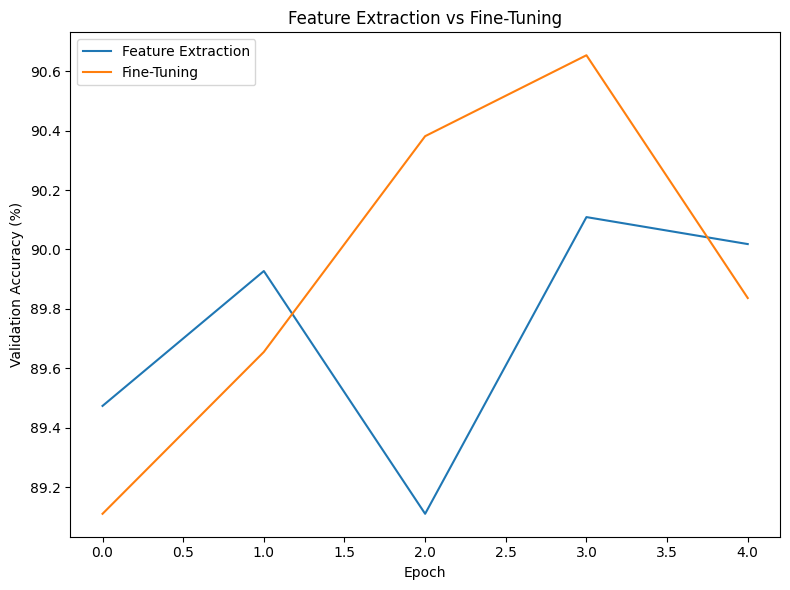

In [27]:
plt.figure(figsize=(8,6))

plt.plot(
    np.array(feature_history.history["val_accuracy"])*100,
    label="Feature Extraction"
)

plt.plot(
    np.array(fine_history.history["val_accuracy"])*100,
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.tight_layout()
plt.savefig("images/transfer_learning_fine_tuning.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [28]:
configs={
    "C1":{"lr":0.001,"dropout":0.0,"batch":32},
    "C2":{"lr":0.001,"dropout":0.25,"batch":32},
    "C3":{"lr":0.0001,"dropout":0.25,"batch":32},
    "C4":{"lr":0.0001,"dropout":0.5,"batch":32}
}

print(configs)

{'C1': {'lr': 0.001, 'dropout': 0.0, 'batch': 32}, 'C2': {'lr': 0.001, 'dropout': 0.25, 'batch': 32}, 'C3': {'lr': 0.0001, 'dropout': 0.25, 'batch': 32}, 'C4': {'lr': 0.0001, 'dropout': 0.5, 'batch': 32}}


In [29]:
cv_results = {}

for config_name, config in configs.items():

    fold_scores = []

    kfold = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for fold, (train_idx, val_idx) in enumerate(kfold.split(x_train)):

        def train_generator():
            indices = train_idx.copy()
            np.random.seed(42)
            np.random.shuffle(indices)

            for start in range(0, len(indices), config["batch"]):
                batch_idx = indices[start:start + config["batch"]]

                yield (
                    x_train[batch_idx],
                    y_train[batch_idx]
                )

        def val_generator():
            for start in range(0, len(val_idx), config["batch"]):
                batch_idx = val_idx[start:start + config["batch"]]

                yield (
                    x_train[batch_idx],
                    y_train[batch_idx]
                )

        output_signature = (
            tf.TensorSpec(
                shape=(None, 224, 224, 3),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(None,),
                dtype=tf.int32
            )
        )

        fold_train = tf.data.Dataset.from_generator(
            train_generator,
            output_signature=output_signature
        )

        fold_val = tf.data.Dataset.from_generator(
            val_generator,
            output_signature=output_signature
        )

        model = build_model(dropout=config["dropout"])

        model.compile(
            optimizer=Adam(learning_rate=config["lr"]),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            fold_train,
            validation_data=fold_val,
            epochs=3,
            steps_per_epoch=int(np.ceil(len(train_idx) / config["batch"])),
            validation_steps=int(np.ceil(len(val_idx) / config["batch"])),
            verbose=0
        )

        fold_scores.append(
            max(history.history["val_accuracy"])
        )

        del model
        del fold_train
        del fold_val
        del history

        tf.keras.backend.clear_session()

    cv_results[config_name] = [
        *fold_scores,
        np.mean(fold_scores),
        np.std(fold_scores)
    ]


cv_table = pd.DataFrame(
    cv_results,
    index=["F1", "F2", "F3", "F4", "F5", "Mean", "SD"]
).T

print(cv_table)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


          F1        F2        F3        F4        F5      Mean        SD
C1  0.896987  0.910593  0.894072  0.886297  0.881323  0.893854  0.010042
C2  0.893100  0.896016  0.903790  0.906706  0.891051  0.898132  0.006090
C3  0.798834  0.817298  0.797862  0.811467  0.812257  0.807544  0.007776
C4  0.725947  0.697765  0.742468  0.724976  0.713035  0.720838  0.014862


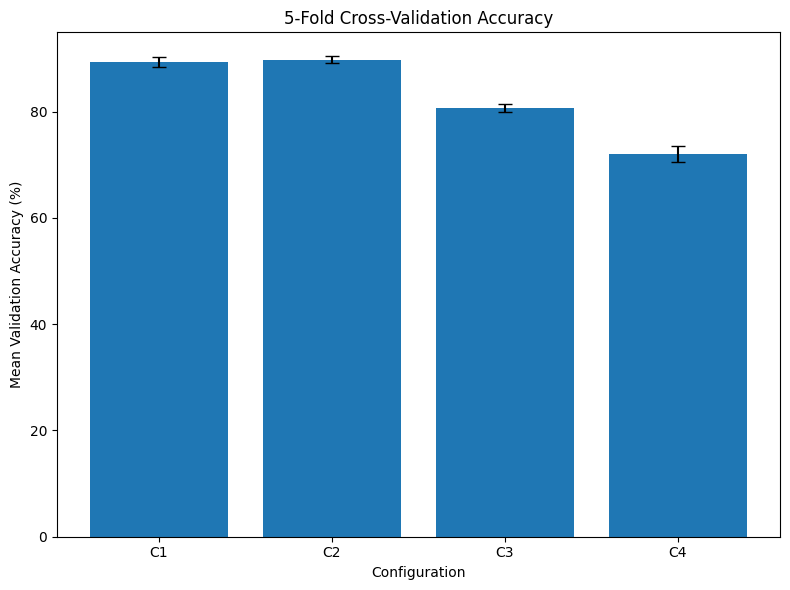

In [30]:
plt.figure(figsize=(8,6))

means=cv_table["Mean"].values*100
stds=cv_table["SD"].values*100

plt.bar(cv_table.index,means,yerr=stds,capsize=5)

plt.xlabel("Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation Accuracy")
plt.tight_layout()
plt.savefig("images/cross_validation_accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [31]:
best_config=cv_table["Mean"].idxmax()

print("Best Configuration:",best_config)
print("Mean CV Accuracy:",cv_table.loc[best_config,"Mean"])
print("CV Standard Deviation:",cv_table.loc[best_config,"SD"])

Best Configuration: C2
Mean CV Accuracy: 0.8981323719024659
CV Standard Deviation: 0.006090425071504066


In [32]:
best=configs[best_config]

final_model=build_model(dropout=best["dropout"])

final_model.compile(
    optimizer=Adam(learning_rate=best["lr"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_start=time.time()

final_history=final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

final_time=time.time()-final_start

Epoch 1/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.7222 - loss: 1.0219 - val_accuracy: 0.9011 - val_loss: 0.3431
Epoch 2/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8841 - loss: 0.3505 - val_accuracy: 0.9047 - val_loss: 0.3000
Epoch 3/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9253 - loss: 0.2350 - val_accuracy: 0.9129 - val_loss: 0.2830
Epoch 4/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9448 - loss: 0.1713 - val_accuracy: 0.9093 - val_loss: 0.2931
Epoch 5/5
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9578 - loss: 0.1292 - val_accuracy: 0.9165 - val_loss: 0.2679


In [33]:
test_loss,test_accuracy=final_model.evaluate(test_ds,verbose=0)

pred_prob=final_model.predict(test_ds)
pred=np.argmax(pred_prob,axis=1)

final_precision=precision_score(y_test,pred,average="weighted")
final_recall=recall_score(y_test,pred,average="weighted")
final_f1=f1_score(y_test,pred,average="weighted")

print("Mean CV Accuracy:",cv_table.loc[best_config,"Mean"])
print("CV Standard Deviation:",cv_table.loc[best_config,"SD"])
print("Test Accuracy:",test_accuracy)
print("Precision:",final_precision)
print("Recall:",final_recall)
print("F1-score:",final_f1)
print("Training Time:",final_time)
print("Number of Parameters:",final_model.count_params())

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step
Mean CV Accuracy: 0.8981323719024659
CV Standard Deviation: 0.006090425071504066
Test Accuracy: 0.9129646420478821
Precision: 0.9160383975458548
Recall: 0.9129646418857661
F1-score: 0.9129989150100983
Training Time: 43.08322334289551
Number of Parameters: 2426725


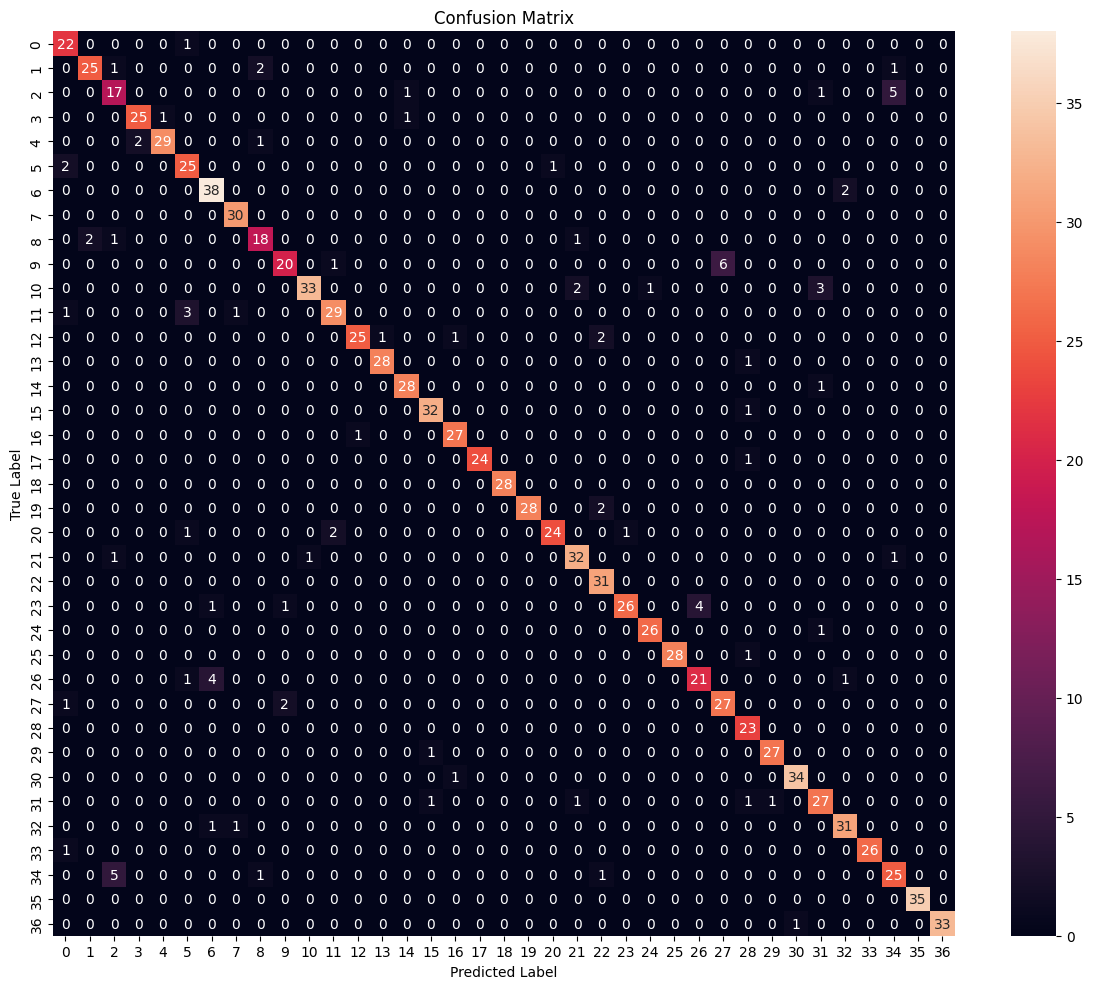

In [34]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=range(37),
    yticklabels=range(37)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("images/confusion_matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()